<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-6---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo_VI_Equipo_15_Habits_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea Módulo VI - Aprendizaje No Supervisado**


---


**Autores:**
- Gabriela Alfaro Prieto
- Casandra Medea Badillo Salas
- Emmanuel Cruz Durán
- Gabriela Pérez González
- Livia Alejandra Rupit Rupit


---


**Metodologías:**

* Técnicas de agrupamiento o clustering: Clusters por métodos aglomerativos y por método de K-MEANS

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import plotly.express as px

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [28]:
df_habits = pd.read_csv("habits - habits.csv", sep=',', encoding='utf-8')

print(df_habits.shape)
print(df_habits.info())
print(df_habits.head())

(1000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 no

### **Construcción de una variable de comparación**

Como el conjunto de datos no contiene una clasificación natural de los estudiantes (una etiqueta binaria natural), construimos una a partir de un umbral de aprobación (`exam_score >= 60`) denominada `performance_group`.

**OJO:** Esta variable no participa en el proceso de clustering; únicamente se utiliza posteriormente para evaluar si los grupos encontrados presentan relación con el desempeño académico.

In [3]:
df_habits["performance_group"] = np.where(
    df_habits["exam_score"] >= 60, "Aprobado", "No aprobado"
)
print(df_habits["performance_group"].value_counts())

performance_group
Aprobado       720
No aprobado    280
Name: count, dtype: int64


**Columnas predictoras:** TODO menos `exam_score` y `performance_group` (se decide excluir `exam_score` porque es un "resultado", no un hábito)

In [4]:
# creamos un df igual al original, solo sin las dos variables que mencionamos arriba solo para no hacernos bolas.
df_habits_copia = df_habits.copy().drop(columns=['performance_group', 'exam_score'])

col_categoricas = df_habits_copia.select_dtypes(include=['object', 'category']).columns.tolist()
print(col_categoricas)

col_numericas = df_habits_copia.select_dtypes(include=['number']).columns.tolist()
print(col_numericas)

['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']


Antes de aplicar K-Means es necesario determinar el número de grupos K. Consideraremos los siguientes tres enfoques para evaluar la calidad de los grupos:

- Método del codo (WSS/TSS).
- Validación cruzada mediante K-Fold.
- Índice de Silueta.

La combinación de estos criterios permite seleccionar un número de grupos que produzca grupos compactos y bien separados.

### **Preprocesamiento de datos**

Dado que el algoritmo *K-Means* utiliza distancias y solo funciona con números, realizamos las siguientes transformaciones:

* Imputación de valores faltantes en variables categóricas.
* Estandarización de variables numéricas.
* Codificación One-Hot de variables categóricas.

Imputaremos los datos en missing (en la estadística descriptiva vimos que solo la variable `parental_education_level` contenia 91 vacíos).

In [5]:
df_habits_copia[col_categoricas] = df_habits_copia[col_categoricas].fillna("Unknown")
# comprobamos ya no tener vacíos
print(df_habits_copia.isna().sum())

age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
dtype: int64


In [6]:
# A las columnas numericas aplicaremos StandarScaler para normalizar las variables,
# y a las categóricas aplicaremos OneHotEncoder creando variables dummy por categoría.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), col_numericas),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), col_categoricas),
    ]
)

habits_scaled = preprocessor.fit_transform(df_habits_copia)
print(habits_scaled)

[[ 1.08455114 -2.41806844 -1.11406369 ...  0.          0.
   1.        ]
 [-0.21586989  2.28170684  0.25131502 ...  0.          0.
   0.        ]
 [ 0.21760379 -1.46449085  0.50732352 ...  0.          1.
   0.        ]
 ...
 [-0.21586989 -0.37468788  0.08064268 ...  1.          0.
   1.        ]
 [ 1.51802481  1.26001656  1.36068521 ...  0.          0.
   0.        ]
 [-0.64934357  0.51077703  0.33665119 ...  0.          0.
   0.        ]]


In [26]:
# Le ponemos sus nombres a cada variable ya que ahora habits_scaled es un array
feature_names = (
    col_numericas
    + list(preprocessor.named_transformers_["cat"].get_feature_names_out(col_categoricas))
)
habits_scaled = pd.DataFrame(habits_scaled, columns=feature_names)
print(habits_scaled.shape)
habits_scaled.head()

(1000, 19)


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_Unknown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,1.084551,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.215870,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.217604,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.084551,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4,-0.649344,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


   num_clusters  sse_within_total  sse_total  sse_ratio
0             1       9904.362000   9904.362   1.000000
1             2       9124.766736   9904.362   0.921288
2             3       8666.707996   9904.362   0.875040
3             4       8250.227894   9904.362   0.832989
4             5       7941.686631   9904.362   0.801837
5             6       7690.466424   9904.362   0.776473
6             7       7464.683370   9904.362   0.753676
7             8       7242.809692   9904.362   0.731275
8             9       7048.329364   9904.362   0.711639
9            10       6930.316437   9904.362   0.699724


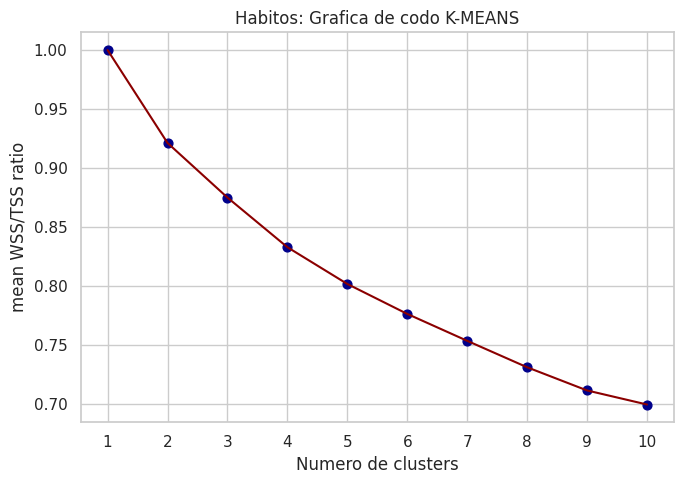

In [8]:
# Metodo del codo: SSE (inertia) y razon WSS/TSS
def sse_ratio_curve(X, k_range=range(1, 11), seed=123):
    tss = np.sum((X - X.mean(axis=0)) ** 2)
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        wss = km.inertia_
        rows.append({"num_clusters": k, "sse_within_total": wss,
                     "sse_total": tss, "sse_ratio": wss / tss})
    return pd.DataFrame(rows)

elbow_df = sse_ratio_curve(habits_scaled.values)
print(elbow_df)

plt.figure(figsize=(7, 5))
plt.plot(elbow_df["num_clusters"], elbow_df["sse_ratio"], color="darkred")
plt.scatter(elbow_df["num_clusters"], elbow_df["sse_ratio"], color="darkblue", s=40)
plt.xlabel("Numero de clusters")
plt.ylabel("mean WSS/TSS ratio")
plt.title("Habitos: Grafica de codo K-MEANS")
plt.xticks(range(1, 11))
plt.tight_layout()


   num_clusters      mean           std
0             1  1.000000  8.143317e-16
1             2  0.921163  6.442592e-04
2             3  0.871969  1.244964e-03
3             4  0.831554  1.592744e-03
4             5  0.800002  1.198859e-03
5             6  0.773172  1.499922e-03
6             7  0.748549  1.756438e-03
7             8  0.727777  2.547108e-03
8             9  0.709836  2.043810e-03
9            10  0.694998  1.386408e-03


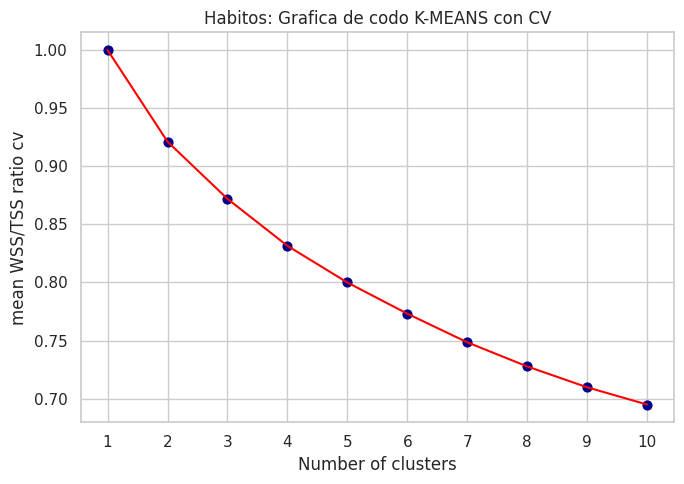

In [9]:
# Validacion cruzada (K-fold) sobre el SSE ratio
def sse_ratio_cv(X, k_range=range(1, 11), n_splits=10, seed=123):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    for k in k_range:
        ratios = []
        for train_idx, _ in kf.split(X):
            X_train = X[train_idx]
            km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X_train)
            tss = np.sum((X_train - X_train.mean(axis=0)) ** 2)
            ratios.append(km.inertia_ / tss)
        rows.append({"num_clusters": k, "mean": np.mean(ratios), "std": np.std(ratios)})
    return pd.DataFrame(rows)

cv_df = sse_ratio_cv(habits_scaled.values)
print(cv_df)

plt.figure(figsize=(7, 5))
plt.plot(cv_df["num_clusters"], cv_df["mean"], color="red")
plt.scatter(cv_df["num_clusters"], cv_df["mean"], color="darkblue", s=40)
plt.xlabel("Number of clusters")
plt.ylabel("mean WSS/TSS ratio cv")
plt.title("Habitos: Grafica de codo K-MEANS con CV")
plt.xticks(range(1, 11))
plt.tight_layout()

   num_clusters      mean
0             2  0.076864
1             3  0.065043
2             4  0.068755
3             5  0.067342
4             6  0.067147
5             7  0.068302
6             8  0.070781
7             9  0.071442
8            10  0.071543
Mejor K segun silueta: 2


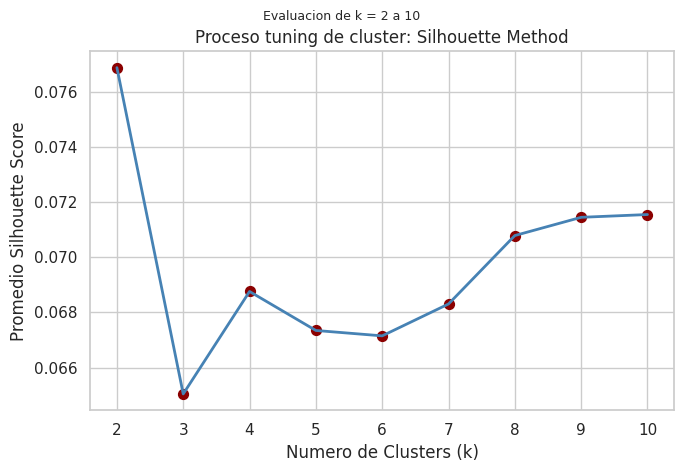

In [10]:
# Silhouette Method
def silhouette_curve(X, k_range=range(2, 11), seed=123):
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        score = silhouette_score(X, km.labels_)
        rows.append({"num_clusters": k, "mean": score})
    return pd.DataFrame(rows)

sil_df = silhouette_curve(habits_scaled.values)
print(sil_df)
best_k = int(sil_df.loc[sil_df["mean"].idxmax(), "num_clusters"])
print(f"Mejor K segun silueta: {best_k}")

plt.figure(figsize=(7, 5))
plt.plot(sil_df["num_clusters"], sil_df["mean"], color="steelblue", linewidth=2)
plt.scatter(sil_df["num_clusters"], sil_df["mean"], color="darkred", s=50)
plt.title("Proceso tuning de cluster: Silhouette Method")
plt.suptitle("Evaluacion de k = 2 a 10", y=0.94, fontsize=9)
plt.xlabel("Numero de Clusters (k)")
plt.ylabel("Promedio Silhouette Score")
plt.tight_layout()

**Selección del número de conglomerados**

El *Silhouette Method* alcanzó su valor máximo para `K=2`, por lo que éste será el número de grupos utilizado en el resto del análisis.

No obstante, el valor es relativamente bajo (≈0.08), lo cual indica que la separación entre grupos es limitada. Esto sugiere que los hábitos de los estudiantes presentan una transición gradual más que grupos claramente diferenciados.

In [11]:
kmeans_final = KMeans(n_clusters=best_k, n_init=25, random_state=123)
clusters = kmeans_final.fit_predict(habits_scaled.values)
df_habits["cluster"] = clusters

centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=habits_scaled.columns)
print("Centroides:\n", centroids)

wss = kmeans_final.inertia_
tss = np.sum((habits_scaled.values - habits_scaled.values.mean(axis=0)) ** 2)
print(f"SSE within total: {wss:.2f}")
print(f"SSE total: {tss:.2f}")
print(f"SSE ratio: {wss / tss:.4f}")

sil_avg = silhouette_score(habits_scaled.values, clusters)
print(f"Silueta promedio: {sil_avg:.4f}")

Centroides:
         age  study_hours_per_day  social_media_hours  netflix_hours  \
0 -0.014704            -0.144560           -0.139243       0.071474   
1  0.015614             0.153501            0.147856      -0.075895   

   attendance_percentage  sleep_hours  exercise_frequency  \
0              -0.023320     0.031205            0.827157   
1               0.024762    -0.033135           -0.878321   

   mental_health_rating  gender_Male  gender_Other  part_time_job_Yes  \
0             -0.001071     0.520388      0.036893           0.213592   
1              0.001137     0.430928      0.047423           0.216495   

   diet_quality_Good  diet_quality_Poor  parental_education_level_High School  \
0           0.384466           0.194175                              0.398058   
1           0.371134           0.175258                              0.385567   

   parental_education_level_Master  parental_education_level_Unknown  \
0                         0.149515                   

In [12]:
# Comparacion (validacion) contra el grupo de desempeno academico
TC = pd.crosstab(df_habits["performance_group"], df_habits["cluster"])
print(TC)

cluster              0    1
performance_group          
Aprobado           371  349
No aprobado        144  136


La distribución de estudiantes aprobados y no aprobados es muy similar en ambos grupos, lo que sugiere que los grupos identificados mediante K-Means no corresponden directamente al desempeño académico.

In [13]:
# Perfil de cada cluster en variables clave
print(
    df_habits.groupby("cluster")[
        ["study_hours_per_day", "sleep_hours", "social_media_hours",
         "netflix_hours", "mental_health_rating", "exam_score"]
    ].mean().round(2)
)

         study_hours_per_day  sleep_hours  social_media_hours  netflix_hours  \
cluster                                                                        
0                       3.34         6.51                2.34           1.90   
1                       3.78         6.43                2.68           1.74   

         mental_health_rating  exam_score  
cluster                                    
0                        5.43       70.21  
1                        5.44       68.96  


Observemos que ambos grupos presentan características relativamente similares. Sin embargo, el segundo grupo muestra ligeramente más horas de estudio, mayor uso de redes sociales y menor consumo de Netflix. En contraste, las diferencias en salud mental y calificación del examen son mínimas.

**Distribución de las variables por grupo**

Los boxplots nos permiten comparar la distribución de cada variable numérica entre los 2 grupos.

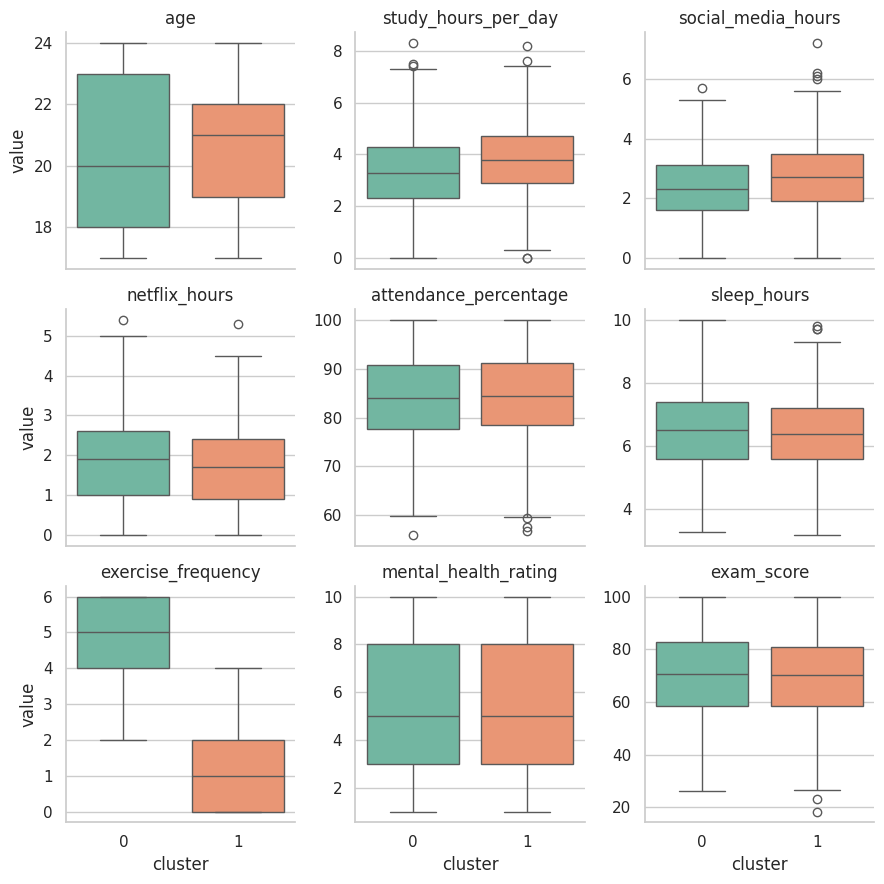

In [14]:
# Boxplots por cluster en variables numericas clave
key_vars = col_numericas + ["exam_score"]
melt_df = df_habits.melt(id_vars="cluster", value_vars=key_vars)
g = sns.FacetGrid(melt_df, col="variable", col_wrap=3, sharey=False, height=3)
g.map_dataframe(sns.boxplot, x="cluster", y="value", hue="cluster",
                 palette="Set2", legend=False)
g.set_titles("{col_name}")
g.tight_layout()

Aquí notamos que existe un amplio traslape entre ambos grupos para la mayoría de las variables. Esto coincide con el bajo valor obtenido en el Silhouette Method.

### **¿Qué pasa si hacemos clusters, primero haciendo reducción de dimensión a través de PCA?**

In [15]:
pca = PCA(random_state=123)
pca.fit(habits_scaled.values)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_comp_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Componentes necesarios para 90% de varianza: {n_comp_90}")

Componentes necesarios para 90% de varianza: 12


In [16]:
varianza = pd.DataFrame({
    "Componente": range(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

print(varianza)

    Componente  Varianza  Acumulada
0            1  0.109850   0.109850
1            2  0.107497   0.217347
2            3  0.104843   0.322190
3            4  0.102567   0.424757
4            5  0.099900   0.524658
5            6  0.096561   0.621218
6            7  0.095384   0.716603
7            8  0.092896   0.809499
8            9  0.029449   0.838948
9           10  0.028638   0.867586
10          11  0.026125   0.893711
11          12  0.024455   0.918166
12          13  0.021863   0.940029
13          14  0.016923   0.956952
14          15  0.012367   0.969319
15          16  0.011017   0.980336
16          17  0.009786   0.990122
17          18  0.006093   0.996216
18          19  0.003784   1.000000


In [17]:
# Esto lo heredamos del ejercicio en R pero aplicado a nuestro ejercicio,
# con 4 componentes, solo explicamos el 42.5% de la variabilidad
# n_comp = min(4, n_comp_90)

# Entonces dejaremos que el número de componentes lo tome de la reducción del PCA
n_comp = n_comp_90
pca = PCA(n_components=n_comp, random_state=123)
pcs = pca.fit_transform(habits_scaled.values)
pcs_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(n_comp)])
print(f"Varianza explicada con {n_comp} CP: {pca.explained_variance_ratio_.sum():.3f}")

Varianza explicada con 12 CP: 0.918


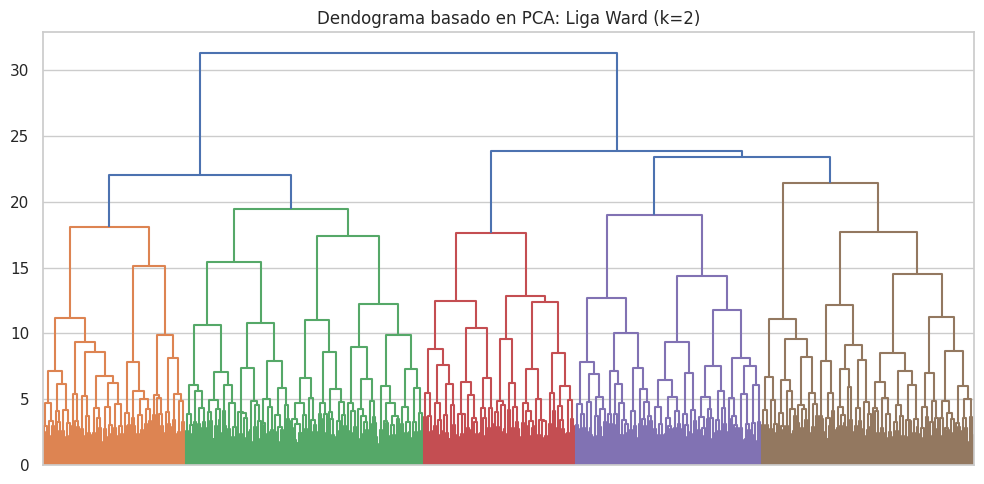

In [18]:
# Clustering jerarquico (liga Ward) sobre las CP
Z = linkage(pcs_df.values, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title(f"Dendograma basado en PCA: Liga Ward (k={best_k})")
plt.tight_layout()

hier_clusters = fcluster(Z, t=best_k, criterion="maxclust")

In [19]:
# K-Means sobre las CP derivado del PCA
kmeans_pca = KMeans(n_clusters=best_k, n_init=25, random_state=123)
clusters_pca = kmeans_pca.fit_predict(pcs_df.values)

TC_CP = pd.crosstab(df_habits["performance_group"], clusters_pca)
print(TC_CP)

col_0                0    1
performance_group          
Aprobado           371  349
No aprobado        143  137


Podemos comprobar si hacer PCA realmente mejora el clustering.

In [20]:
# K-Means con todas las variables
sil_original = silhouette_score(habits_scaled, clusters)

# K-Means con PCA
sil_pca = silhouette_score(pcs, clusters_pca)

print(sil_original)
print(sil_pca)

0.07686437948908792
0.08409122839663762


Vemos que PCA esta mejorando el clustering.

La reducción de dimensionalidad produjo una ligera mejora en el índice de Solhouette (de 0.0769 a 0.0841). Aunque la diferencia es pequeña, indica que el espacio definido por las componentes principales genera grupos ligeramente más compactos y separados.

In [21]:
# Comparacion: clustering con todas las variables vs. clustering con CP
print(pd.crosstab(df_habits["cluster"], clusters_pca))

sil_avg_pca = silhouette_score(pcs_df.values, clusters_pca)
print(f"Silueta promedio (PCA): {sil_avg_pca:.4f}")

col_0      0    1
cluster          
0        508    7
1          6  479
Silueta promedio (PCA): 0.0841


In [22]:
centroids_pca = pd.DataFrame(
    kmeans_pca.cluster_centers_,
    columns=pcs_df.columns
)
# print(centroids_pca)

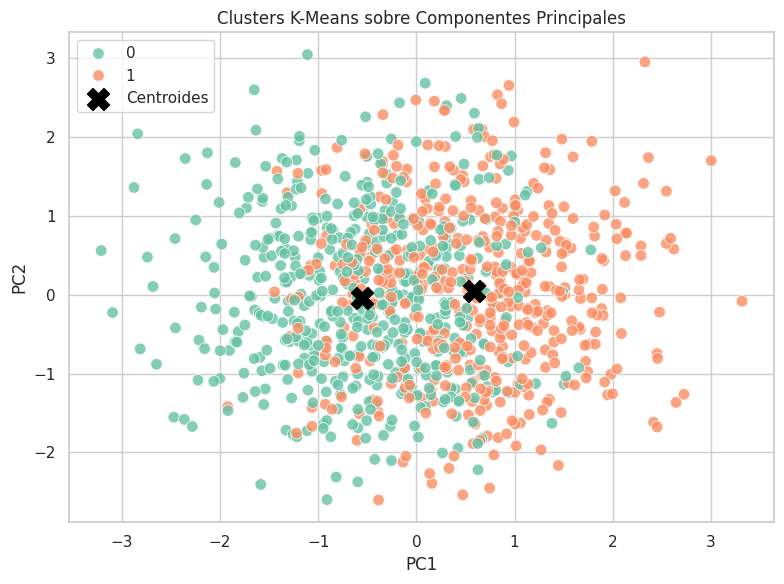

In [23]:
pcs_df["cluster"] = clusters_pca.astype(str)
# print(pcs_df)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pcs_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=70,
    alpha=0.8
)

plt.scatter(
    centroids_pca["PC1"],
    centroids_pca["PC2"],
    marker="X",
    s=250,
    color="black",
    label="Centroides"
)

plt.title("Clusters K-Means sobre Componentes Principales")
plt.legend()
plt.tight_layout()
plt.show()

La proyección de los estudiantes sobre las dos primeras componentes principales muestra que la separación entre grupos ocurre principalmente sobre la primera componente principal (PC1).

No obstante, existe un traslape considerable entre ambos grupos, consistente con el bajo valor del índice de silueta.

In [24]:
pcs_df["cluster"] = clusters_pca.astype(str)
pcs_df["performance_group"] = df_habits["performance_group"].values
pcs_df["exam_score"] = df_habits["exam_score"].values

fig1 = px.scatter(pcs_df, x="PC1", y="PC2", symbol="cluster", color="cluster",
                   title="Habitos: Clusters en espacio PCA")
fig1.show()

fig2 = px.scatter(pcs_df, x="PC1", y="PC2", symbol="cluster", color="exam_score",
                   color_continuous_scale="Viridis",
                   title="Habitos: Clusters en espacio PCA vs. calificacion de examen")
fig2.show()

---
## Conclusiones

Se aplicó el algoritmo *K-Means* para identificar grupos de estudiantes a partir de sus hábitos de estudio y estilo de vida.

El número óptimo de grupos fue determinado mediante Silhouette Method.

Posteriormente se evaluó el uso de PCA como técnica de reducción de dimensionalidad de donde obtuvimos que convenia conservar 12 componentes principales para explicar al menos el 90% de la variabilidad, lo que sugiere una estructura de datos más compleja y menos correlacionada.

Finalmente se compararon ambos enfoques mediante Silhouette Method y la visualización en el espacio PCA, permitiendo evaluar si la reducción de dimensionalidad mejoró la separación entre los grupos.